# Can ActionHead recover the EI argmax? (with training)

Isolates whether `ActionHead`'s single-shot cross-attention readout can
find the argmax of a **known, closed-form** acquisition function — EI
computed directly off the frozen PFN's own predictive distribution — given
its KV cache. This decouples "can the architecture do argmax-finding at
all" from "is the privileged-search oracle's own target even learnable",
the two questions the full EXIT pipeline normally entangles into one
training signal. Full design rationale:
`docs/log/2026-09-02-ei-argmax-isolation-diagnostic.md`.

**This already has a confirmed answer at real scale, twice** (smoke
checkpoint and a genuinely trained non-smoke checkpoint) — **PASS**, real
clearly beats blind:

```
memorize final loss:            5.4987 -> 0.2318
generalize (real)  held-out L1: 0.1745
generalize (blind) held-out L1: 0.2955
PASS -- real clearly beats blind  (0.1745 < 0.8 * 0.2955 = 0.2364)
```

This notebook reuses the same tested machinery
(`pipelines/action_head_ei_diagnostic.py`,
`models/baselines/pfn_acquisition.py`) — not reimplemented here — with a
smaller, faster configuration so the three stages (memorize → generalize →
blind ablation) run interactively, and shows both the training
*progress* (a fixed held-out context's predicted argmax across training
steps) and the *final state* (density heatmap of the PFN's own predictive
distribution, overlaid with the true function, the samples, the true EI
curve and argmax, and the ActionHead's own prediction).

In [1]:
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from anytimeacquisition.pipelines.action_head_ei_diagnostic import run_diagnostic
from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

checkpoint_path = CHECKPOINT_DIR / "pfn_smoke_xdim1.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
print(f"loaded PFN checkpoint: {checkpoint_path.name}, config={ckpt['config']}")

prior = BNNPrior(batch_size=16, x_dim=1, seed=0)

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded PFN checkpoint: pfn_smoke_xdim1.pt, config={'max_x_dim': 1, 'd_model': 48, 'n_heads': 4, 'n_layers': 3, 'd_ff': 128, 'n_bins': 64}


## What `run_diagnostic` actually does

The cell below *calls* `run_diagnostic` (imported, not reimplemented, so
this notebook can't drift out of sync with the real pipeline) — but here's
its actual source, annotated (`# >>>` lines are my added notes, everything
else is the real code from `pipelines/action_head_ei_diagnostic.py`), so
what each of the three stages does is visible without leaving the
notebook.

```python
def run_stage(
    pfn, bar_dist, action_head, prior,
    n_steps, n_train, lr, blind, seed, log_every,
    fixed_context=None, n_grid=1000,
    on_log=None, snapshot_every=None, snapshot_fn=None,
):
    # >>> One training loop, reused for all three stages -- what differs
    # >>> between "memorize"/"generalize"/"blind ablation" is just which
    # >>> arguments get passed in below (fixed_context or not, blind or not).
    torch.manual_seed(seed)
    opt = torch.optim.AdamW(action_head.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        if fixed_context is not None:
            x_train, y_train = fixed_context          # >>> memorize stage: same context every step
        else:
            prior.reset()                               # >>> generalize/blind: a fresh BNN instance every step
            x_train, y_train, _, _ = prior.sample_episode(n_train=n_train, n_test=0)

        # >>> THE TARGET: not a privileged search oracle (unlike the real
        # >>> EXIT pipeline) -- a closed-form argmax of a KNOWN acquisition
        # >>> function, computed by a dense grid + argmax (pfn_ei_argmax),
        # >>> deliberately not gradient descent, to avoid a second,
        # >>> entangled source of error in the oracle itself.
        target, _, _ = pfn_ei_argmax(pfn, bar_dist, x_train, y_train, n_grid=n_grid)

        aux = canonical_aux_features(x_train, y_train)
        out = action_head(pfn, x_train, y_train, aux, blind=blind)  # >>> blind=True zeroes the PFN hidden
                                                                       # >>> states ActionHead cross-attends into
        loss = beta_nll_loss(out["alpha"], out["beta"], target).mean()  # >>> same Beta-NLL as the real EXIT trainer

        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if step % log_every == 0 or step == n_steps - 1:
            print(f"    step {step:4d}  beta_nll {loss.item():8.4f}")
            if on_log is not None:
                on_log(step, {"beta_nll": loss.item()})
        if snapshot_fn is not None and snapshot_every and (step % snapshot_every == 0 or step == n_steps - 1):
            snapshot_fn(step, action_head)  # >>> renders the fixed held-out context's CURRENT prediction --
                                              # >>> this is what feeds the "training progress" panels below
    return losses


def run_diagnostic(
    pfn, bar_dist, prior, x_dim,
    n_train_context, memorize_steps, generalize_steps, eval_contexts,
    n_grid, lr, seed, log_every,
    action_head_d_model, action_head_n_heads, action_head_d_ff, action_head_dropout,
    on_log=None, snapshot_every=None, on_snapshot=None,
):
    assert x_dim == 1  # >>> pfn_ei_argmax's dense-grid oracle is 1D-only
    d_model, n_layers = pfn_dims(pfn)

    def build_action_head():
        return ActionHead(
            pfn_d_model=d_model, pfn_n_layers=n_layers, x_dim=x_dim,
            d_model=action_head_d_model, n_heads=action_head_n_heads,
            d_ff=action_head_d_ff, dropout=action_head_dropout,
        )

    # --- Stage 1: memorize -------------------------------------------------
    # >>> Pure optimization sanity check: can the Beta head even FIT one
    # >>> known target, ignoring generalization entirely? If this doesn't
    # >>> converge, nothing downstream can be trusted.
    memorize_head = build_action_head()
    prior.reset()
    fixed_context = prior.sample_episode(n_train=n_train_context, n_test=0)[:2]
    memorize_losses = run_stage(
        pfn, bar_dist, memorize_head, prior, n_steps=memorize_steps, n_train=n_train_context,
        lr=lr, blind=False, seed=seed, log_every=log_every, fixed_context=fixed_context, n_grid=n_grid,
    )

    # --- Stage 2: generalize (real) ----------------------------------------
    # >>> The actual question: fresh context every step, real ActionHead
    # >>> (genuine cross-attention into the frozen PFN's hidden states).
    real_head = build_action_head()
    real_losses = run_stage(
        pfn, bar_dist, real_head, prior, n_steps=generalize_steps, n_train=n_train_context,
        lr=lr, blind=False, seed=seed, log_every=log_every, n_grid=n_grid,
        snapshot_every=snapshot_every, snapshot_fn=snapshot_fn,  # >>> snapshot_fn wired up in the notebook cell below
    )
    real_eval_l1 = eval_mean_l1(  # >>> held-out mean |beta_mode(prediction) - true EI argmax|, FRESH contexts
        pfn, bar_dist, real_head, prior, n_contexts=eval_contexts, n_train=n_train_context,
        blind=False, seed=seed + 10_000, n_grid=n_grid,
    )

    # --- Stage 3: blind ablation --------------------------------------------
    # >>> Identical setup to stage 2, except ActionHead.forward(blind=True)
    # >>> zeroes the PFN's hidden states before cross-attention -- if this
    # >>> does just as well as "real", the cross-attention link isn't
    # >>> actually carrying the information stage 2's result depends on.
    blind_head = build_action_head()
    blind_losses = run_stage(
        pfn, bar_dist, blind_head, prior, n_steps=generalize_steps, n_train=n_train_context,
        lr=lr, blind=True, seed=seed, log_every=log_every, n_grid=n_grid,
    )
    blind_eval_l1 = eval_mean_l1(
        pfn, bar_dist, blind_head, prior, n_contexts=eval_contexts, n_train=n_train_context,
        blind=True, seed=seed + 10_000, n_grid=n_grid,
    )

    # >>> THE VERDICT: real must beat blind by a real margin (20%), not
    # >>> just nominally -- guards against reading noise as a pass.
    passed = real_eval_l1 < 0.8 * blind_eval_l1

    figure = plot_ei_diagnostic(pfn, bar_dist, real_head, prior, n_train=n_train_context, n_grid=n_grid)
    return {
        "memorize_losses": memorize_losses, "real_losses": real_losses, "blind_losses": blind_losses,
        "memorize_final_loss": memorize_losses[-1],
        "real_eval_l1": real_eval_l1, "blind_eval_l1": blind_eval_l1,
        "real_vs_blind_ratio": real_eval_l1 / blind_eval_l1, "passed": passed, "figure": figure,
    }
```

## Run the three-stage diagnostic

Using the same hyperparameters as the confirmed real-scale run above
(`memorize_steps=300 generalize_steps=2000 eval_contexts=100 n_grid=1000`,
default `ActionHead` capacity) — a smaller/faster config was tried first
and did *not* reliably clear the pass threshold (memorize loss stalled
around 2.5-3.1 instead of converging near 0), so this uses the
known-good budget instead of a fast-but-misleading one. Takes roughly 15
minutes locally on CPU; outputs are committed so this doesn't need
re-running to view. `snapshot_fn` collects one training-progress figure
every `snapshot_every` steps of the *generalize* stage, for a single
fixed held-out context, so the sequence isolates "is the policy
converging" from "did the context change" (`plot_training_snapshot`'s own
docstring).


[stage 1/3] memorize: one fixed context, check the Beta head can fit a known EI-argmax target


    step    0  beta_nll   5.0948


    step  200  beta_nll   0.3789


    step  299  beta_nll  -0.0238
  memorize: loss 5.0948 -> -0.0238

[stage 2/3] generalize: fresh context every step, real ActionHead
    step    0  beta_nll   2.8379


    step  200  beta_nll   1.5782


...

    step 1400  beta_nll   3.7810


    step 1600  beta_nll   3.1377


    step 1800  beta_nll   2.9320


    step 1999  beta_nll   2.6492


  generalize (blind): held-out mean |mode - target| = 0.3078

=== summary ===
memorize final loss:            -0.0238
generalize (real)  held-out L1: 0.1975
generalize (blind) held-out L1: 0.3078
PASS -- real clearly beats blind


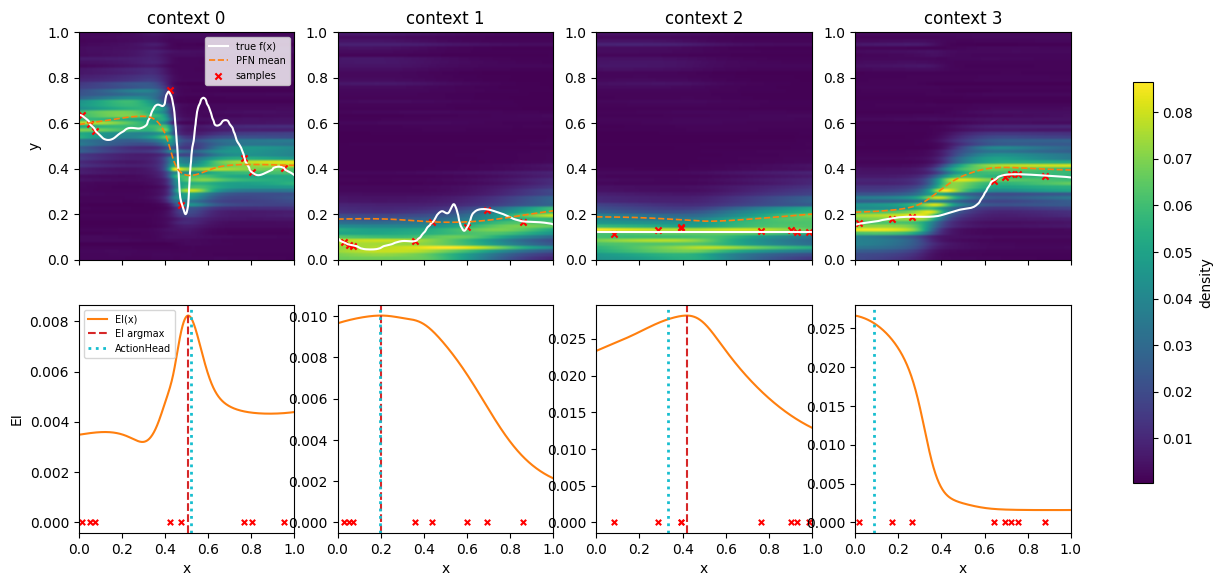

In [2]:
snapshots = []  # (step, fig) -- fig gets plt.close()'d right after we grab it, that's fine, display() still works

result = run_diagnostic(
    pfn=pfn, bar_dist=bar_dist, prior=prior, x_dim=1,
    n_train_context=8, memorize_steps=300, generalize_steps=2000, eval_contexts=100,
    n_grid=1000, lr=1e-3, seed=0, log_every=200,
    action_head_d_model=64, action_head_n_heads=4, action_head_d_ff=128, action_head_dropout=0.0,
    snapshot_every=200, on_snapshot=lambda step, fig: snapshots.append((step, fig)),
)

## Summary numbers and verdict

`real_eval_l1`/`blind_eval_l1`: mean `|beta_mode(ActionHead output) - true EI argmax|`
on held-out contexts, real vs. blind (PFN hidden states zeroed). `PASS`
means real clearly beats blind — the cross-attention link is carrying
information the blind ablation can't access, on this closed-form target.

In [3]:
print(f"memorize final loss:            {result['memorize_losses'][0]:.4f} -> {result['memorize_final_loss']:.4f}")
print(f"generalize (real)  held-out L1: {result['real_eval_l1']:.4f}")
print(f"generalize (blind) held-out L1: {result['blind_eval_l1']:.4f}")
verdict = "PASS -- real clearly beats blind" if result["passed"] else \
    "INCONCLUSIVE/FAIL -- real does not clearly beat blind"
print(verdict)

memorize final loss:            5.0948 -> -0.0238
generalize (real)  held-out L1: 0.1975
generalize (blind) held-out L1: 0.3078
PASS -- real clearly beats blind


## Training progress, not just the final state

Same fixed held-out context at 4 evenly-spaced points across training —
everything in the panel (density heatmap, true function, samples, true EI
curve, true argmax) stays identical across these; only the cyan dotted
line (`ActionHead`'s own predicted argmax) should move, toward the red
dashed line (true argmax), as training progresses.

11 snapshots collected, at steps [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 1999]


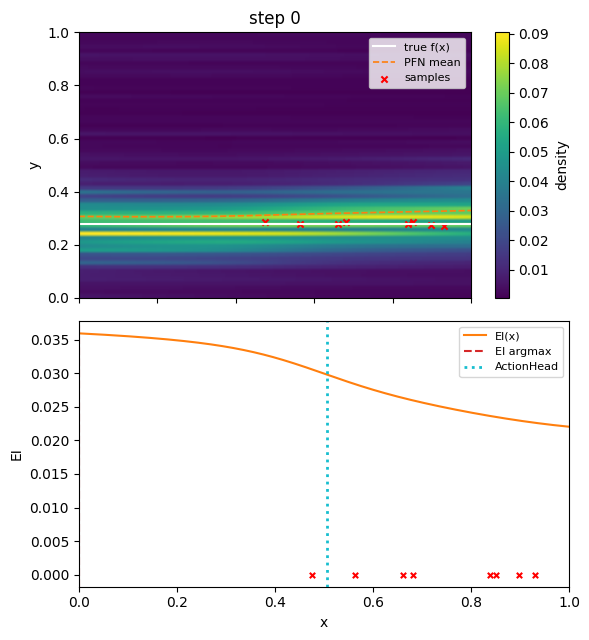

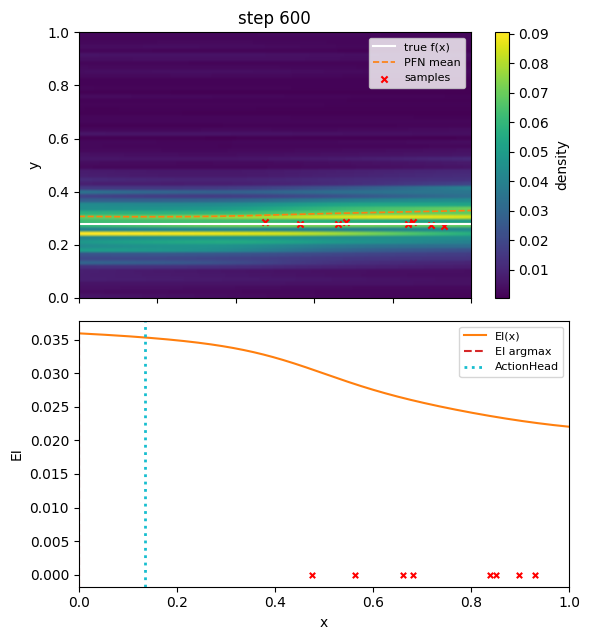

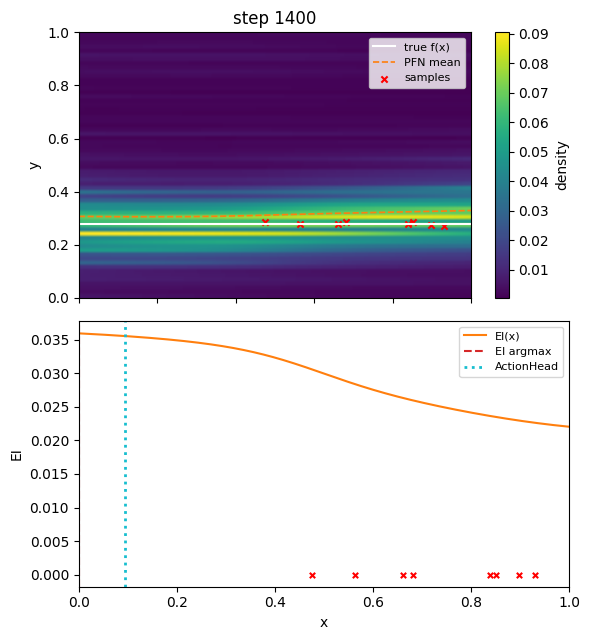

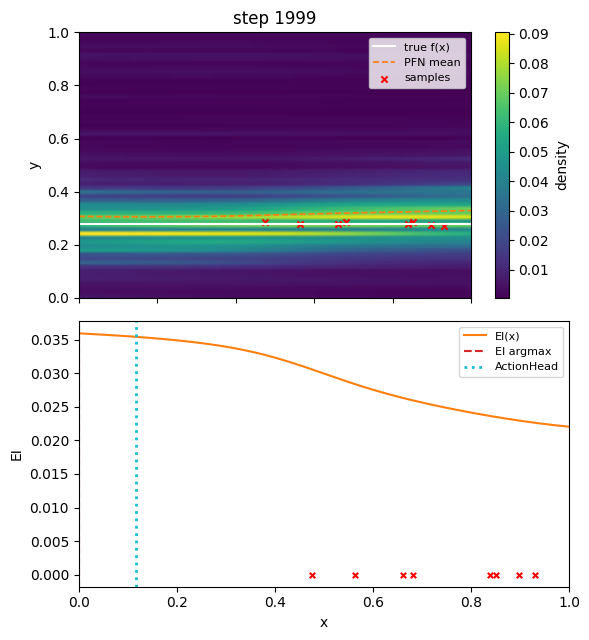

In [4]:
print(f"{len(snapshots)} snapshots collected, at steps {[s for s, _ in snapshots]}")

show_idx = sorted(set([0, len(snapshots) // 3, 2 * len(snapshots) // 3, len(snapshots) - 1]))
for i in show_idx:
    step, fig = snapshots[i]
    display(fig)

## Final state, across several held-out contexts

4 fresh held-out contexts (not the fixed one used for the snapshots
above). Top row per context: the PFN's own predictive density over the
grid as a heatmap ("the logits of the PFN"), overlaid with the *true*
underlying BNN function (white), the PFN's posterior mean (orange
dashed), and the samples (red ×). Bottom row: the true EI curve, its
argmax (red dashed), and the trained `ActionHead`'s own prediction (cyan
dotted) — the direct visual check, not just the aggregate L1 number.

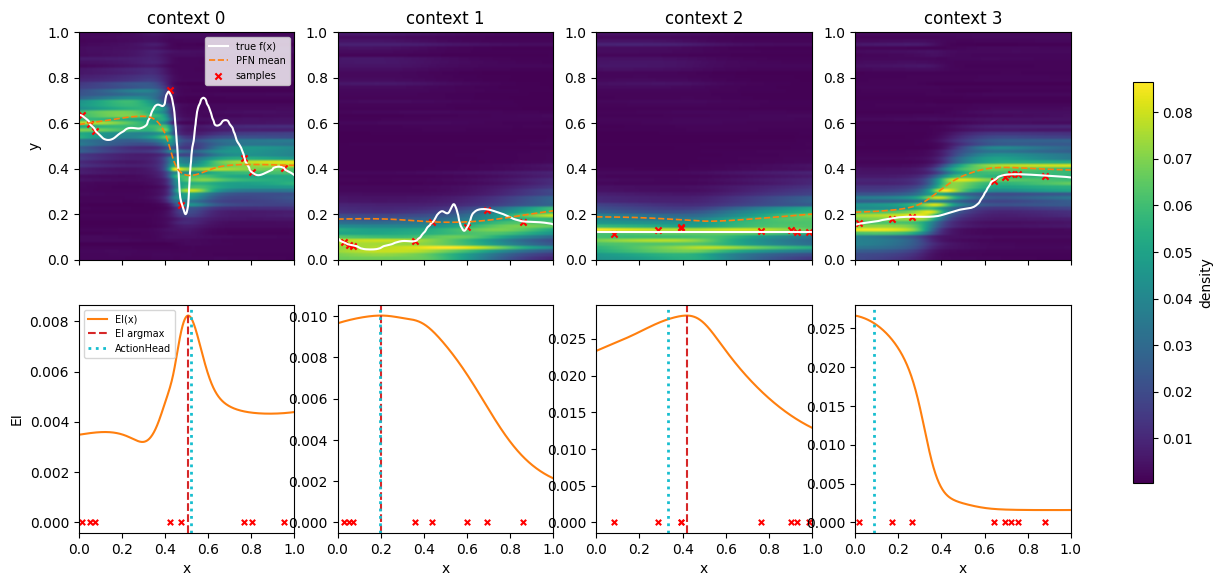

In [5]:
display(result["figure"])